多层感知机

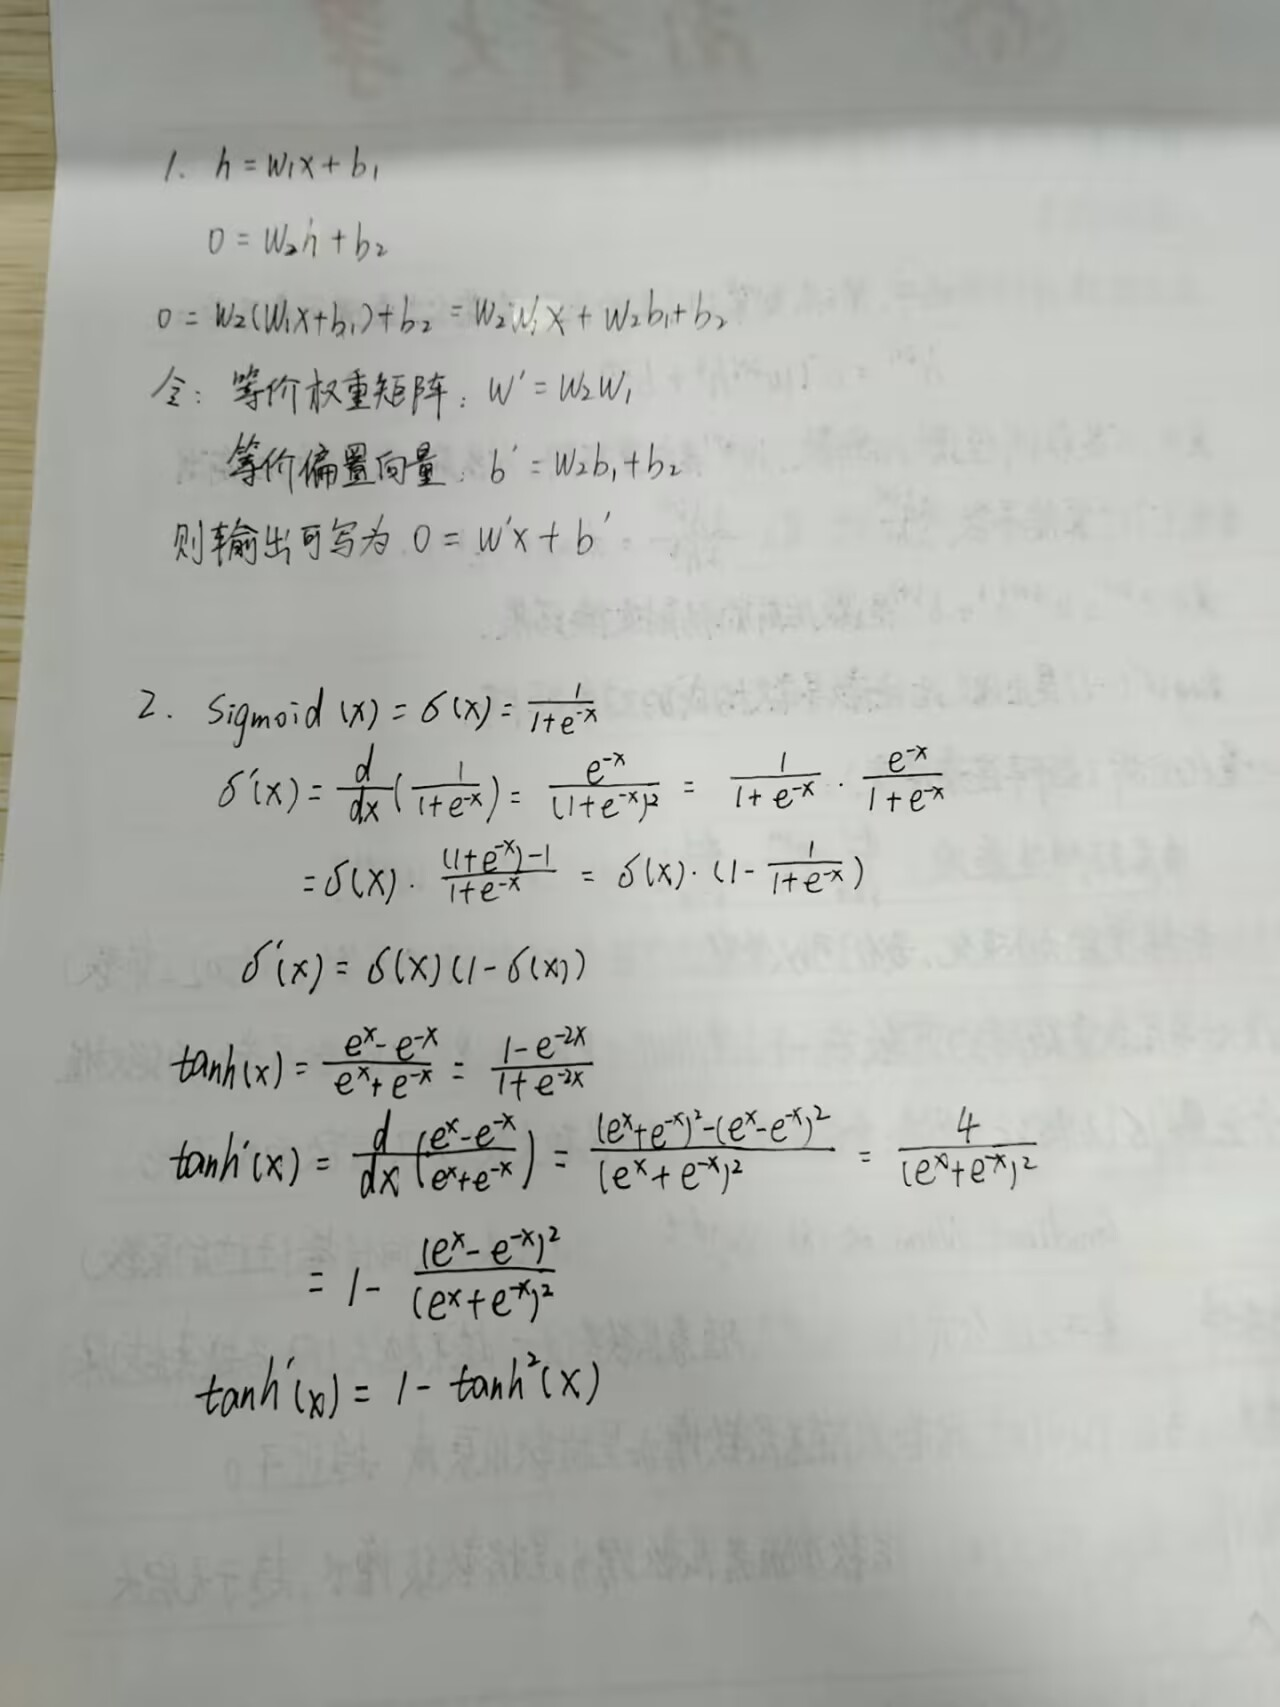

In [2]:
import torch
import torchvision
from torchvision import transforms
from torch.utils.data import DataLoader

# ---------------- 配置部分 ----------------
batch_size = 256
num_epochs = 10
lr = 0.1
num_inputs = 28 * 28
num_outputs = 10
num_hiddens = 256

# ---------------- 数据加载 ----------------
trans = transforms.ToTensor()
mnist_train = torchvision.datasets.FashionMNIST(root="./data", train=True, transform=trans, download=True)
mnist_test = torchvision.datasets.FashionMNIST(root="./data", train=False, transform=trans, download=True)

train_iter = DataLoader(mnist_train, batch_size, shuffle=True)
test_iter = DataLoader(mnist_test, batch_size, shuffle=False)

# ================= 核心实现部分 =================

# 【实现要求 1】：正确初始化参数并保持叶子节点属性
W1 = torch.randn(num_inputs, num_hiddens) * 0.01
b1 = torch.zeros(num_hiddens)
W2 = torch.randn(num_hiddens, num_outputs) * 0.01
b2 = torch.zeros(num_outputs)

# 必须放在运算之后声明需要梯度
for param in [W1, b1, W2, b2]:
    param.requires_grad_(True)

params = [W1, b1, W2, b2]

# 【实现要求 2】：ReLU
def relu(X):
    zeros = torch.zeros_like(X)
    return torch.max(X, zeros)

def net(X):
    X = X.reshape((-1, num_inputs))
    H = relu(torch.matmul(X, W1) + b1)
    return torch.matmul(H, W2) + b2

# 【实现要求 3】：带有 Softmax 的交叉熵
def softmax(X):
    X_max = X.max(dim=1, keepdim=True).values
    X_exp = torch.exp(X - X_max)
    partition = X_exp.sum(dim=1, keepdim=True)
    return X_exp / partition

def cross_entropy(y_hat, y):
    return - torch.log(y_hat[range(len(y_hat)), y] + 1e-8).mean()

# 【实现要求 4】：手动 SGD
def sgd(params, lr):
    with torch.no_grad():
        for param in params:
            param -= lr * param.grad
            param.grad.zero_()

# ================= 辅助函数与训练循环 =================
def evaluate_accuracy(net, data_iter):
    correct = 0; total = 0
    with torch.no_grad():
        for X, y in data_iter:
            logits = net(X)
            y_pred = logits.argmax(axis=1)
            correct += (y_pred == y).sum().item()
            total += y.numel()
    return correct / total

print("开始训练...")
for epoch in range(num_epochs):
    epoch_loss_sum = 0.0
    epoch_items = 0
    
    for X, y in train_iter:
        logits = net(X)
        y_prob = softmax(logits)
        loss = cross_entropy(y_prob, y)
        
        loss.backward()
        sgd(params, lr)
        
        epoch_loss_sum += loss.item() * y.numel()
        epoch_items += y.numel()
        
    test_acc = evaluate_accuracy(net, test_iter)
    avg_loss = epoch_loss_sum / epoch_items
    print(f"Epoch {epoch + 1}/{num_epochs}, Loss: {avg_loss:.4f}, Test Acc: {test_acc:.4f}")

print("训练完成！")

开始训练...
Epoch 1/10, Loss: 1.0422, Test Acc: 0.7213
Epoch 2/10, Loss: 0.6004, Test Acc: 0.7817
Epoch 3/10, Loss: 0.5225, Test Acc: 0.8134
Epoch 4/10, Loss: 0.4792, Test Acc: 0.8256
Epoch 5/10, Loss: 0.4517, Test Acc: 0.8353
Epoch 6/10, Loss: 0.4344, Test Acc: 0.8418
Epoch 7/10, Loss: 0.4150, Test Acc: 0.8410
Epoch 8/10, Loss: 0.4060, Test Acc: 0.8379
Epoch 9/10, Loss: 0.3922, Test Acc: 0.8348
Epoch 10/10, Loss: 0.3807, Test Acc: 0.8428
训练完成！


模型选择，权重衰减和丢弃法

1. 过拟合与欠拟合
（1）简述训练误差（Training Error）与泛化误差（Generalization Error）的区别：
训练误差（Training Error）： 指模型在用于训练的数据集上计算得到的误差。它反映的是模型对已知样本的拟合程度（即模型“记忆”训练数据的能力）。
泛化误差（Generalization Error）： 指模型在未曾见过的新数据（测试集或实际应用数据）上的期望误差。它反映的是模型举一反三的预测能力（即模型真正学到了普遍规律而非死记硬背的能力）。
核心区别： 训练误差低只代表在已知数据上表现好，而泛化误差低才代表模型具有真正的实用价值。
（2）当一个模型的训练误差极低，但泛化误差很高时，模型处于什么状态？
模型处于 过拟合（Overfitting） 状态。这意味着模型由于过于复杂，不仅学到了数据中的普遍规律，还把训练数据集中的噪声（Noise）和由于采样偶然性带来的特有特征当成了全局规律学了进去，导致其丧失了对新数据的适应能力。
（3）应该如何通过控制模型复杂度来缓解这一现象？
针对过拟合，核心思路是降低或限制模型的复杂度。常见的具体控制方法包括：
减少参数数量/简化模型结构： 直接降低模型的理论容量。例如，在神经网络中减少隐藏层的层数或每层的神经元个数；在多项式拟合中降低多项式的最高阶数。
正则化（Regularization）： 在原本的损失函数后面加上一个惩罚项（常见如 L1 正则化 或 L2 正则化/权重衰减）。这会迫使模型在训练时尽量保持权重参数较小或趋近于零，从而使模型变得更平滑，降低复杂度。
提前停止（Early Stopping）： 在迭代训练过程中，划分出一部分数据作为验证集。监控模型在验证集上的误差，当发现训练误差还在下降，但验证集误差已经开始上升时，说明开始过拟合了，此时立刻终止训练。
Dropout（针对神经网络）： 在训练的每次前向传播中，按照一定概率随机让部分神经元“失活”（输出置为0）。这迫使网络不能过度依赖某几个特定的局部特征，相当于训练了多个较简子网络的集合，有效控制了单次前向传播的复杂度。

2. K 折交叉验证
阐述 K 折交叉验证（K-fold Cross-Validation）的具体实施算法步骤：
K 折交叉验证是一种为了更准确评估模型泛化能力、充分利用有限数据的数据划分方法。其具体步骤如下：
（1）数据集划分：将包含全量样本的原始数据集，随机打乱后，尽可能均匀地划分为 K 个互不相交的子集（这些子集被称为“折”或 fold）。
（2）迭代训练与验证： 总共进行 K 次迭代过程。在第 i 次迭代中（i 取值从 1 到 K）：
选择验证集： 将第 i 个子集单独拎出来，作为本次迭代的验证集（或测试集）。
选择训练集： 将剩余的 K−1 个子集合并在一起，作为本次迭代的训练集。
模型评估： 使用合并后的训练集重新训练模型，然后用训练好的模型在刚刚留出的验证集上进行预测，计算并记录下该次迭代的性能评价指标（例如准确率、均方误差等，记为 Ei）。
（3）结果汇总与平均： 经过 K 次迭代后，每个子集都恰好被用作过一次验证集。此时收集到了 K 个独立的性能评估结果（E1,E2,...,Ek）。将这 K 个结果求算术平均值，该平均值即作为该模型在当前数据集上的最终交叉验证性能评估。

正在训练：1. 无正则化模型 (Baseline)...
正在训练：2. 仅加入 L2 权重衰减模型...
正在训练：3. 仅加入 Dropout 机制模型...
训练完成！正在绘制对比曲线...


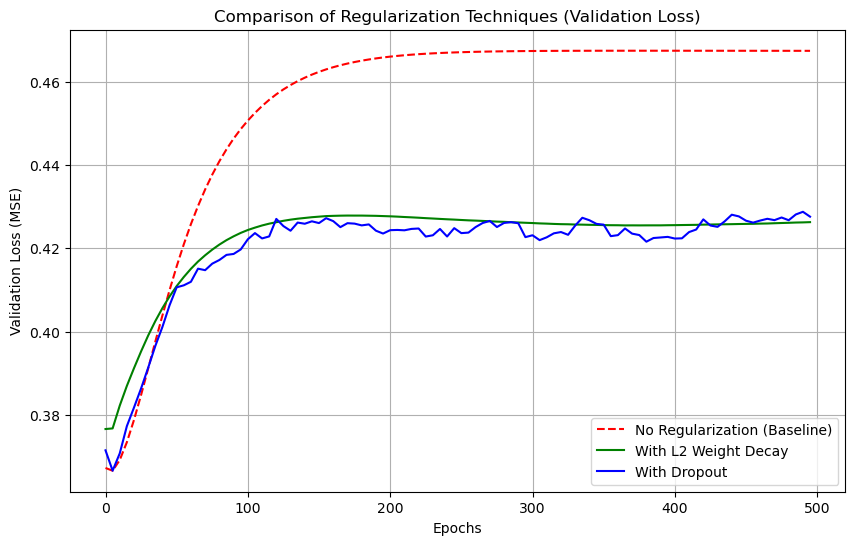

In [6]:
import os
os.environ['KMP_DUPLICATE_LIB_OK'] = 'True' # 解决 PyTorch 与绘图库的底层 OpenMP 冲突

%matplotlib inline 

import torch
import matplotlib.pyplot as plt

def sgd_with_weight_decay(params, lr, weight_decay):
    with torch.no_grad():
        for param in params:
            if param.dim() > 1 and weight_decay > 0:
                param.data = param.data * (1.0 - lr * weight_decay) - lr * param.grad
            else:
                param.data -= lr * param.grad
            param.grad.zero_()

def dropout_layer(X, dropout):
    assert 0 <= dropout <= 1
    if dropout == 1: return torch.zeros_like(X)
    if dropout == 0: return X
    mask = (torch.rand(X.shape) > dropout).float()
    return mask * X / (1.0 - dropout)

def net(X, params, is_training=True, dropout_rate=0.0):
    W1, b1, W2, b2 = params
    H = torch.matmul(X, W1) + b1
    H = torch.max(H, torch.zeros_like(H)) 
    if is_training and dropout_rate > 0:
        H = dropout_layer(H, dropout_rate)
    return torch.matmul(H, W2) + b2

def squared_loss(y_hat, y):
    return (y_hat - y.reshape(y_hat.shape)) ** 2 / 2

# ==========================================
# 终极数据构造：非线性规律 + 强噪声
# ==========================================
torch.manual_seed(42)

num_inputs = 20
num_hiddens = 64   # 适当缩小网络，让计算更稳定
num_outputs = 1
num_train = 20     # 只有20个样本
num_test = 500
num_epochs = 500   # 训练久一点，让过拟合充分暴露
lr = 0.05          # 稍微激进一点的学习率

train_features = torch.randn((num_train, num_inputs))
test_features = torch.randn((num_test, num_inputs))

# 使用正弦函数 sin() 构造高度非线性的真实规律，并加入 0.5 的大噪声
true_w = torch.randn((num_inputs, 1)) * 0.5 
train_labels = torch.sin(torch.matmul(train_features, true_w)) + torch.randn(num_train, 1) * 0.5
test_labels = torch.sin(torch.matmul(test_features, true_w)) + torch.randn(num_test, 1) * 0.5

def init_params():
    # 初始权重加大到 0.1，让模型跳出初始的"平原"地带
    W1 = torch.randn(num_inputs, num_hiddens) * 0.1
    b1 = torch.zeros(num_hiddens)
    W2 = torch.randn(num_hiddens, num_outputs) * 0.1
    b2 = torch.zeros(num_outputs)
    for param in [W1, b1, W2, b2]:
        param.requires_grad_(True)
    return [W1, b1, W2, b2]

def train_experiment(weight_decay=0.0, dropout_rate=0.0):
    params = init_params()
    test_loss_history = []
    
    for epoch in range(num_epochs):
        y_hat = net(train_features, params, is_training=True, dropout_rate=dropout_rate)
        loss = squared_loss(y_hat, train_labels).mean()
        loss.backward()
        sgd_with_weight_decay(params, lr, weight_decay)
        
        # 每 5 轮记录一次，让曲线更平滑
        if epoch % 5 == 0:
            with torch.no_grad():
                test_loss = squared_loss(net(test_features, params, is_training=False), test_labels).mean().item()
                test_loss_history.append(test_loss)
            
    return test_loss_history

# ==========================================
# 运行对比并绘图
# ==========================================
print("正在训练：1. 无正则化模型 (Baseline)...")
test_loss_base = train_experiment(weight_decay=0.0, dropout_rate=0.0)

print("正在训练：2. 仅加入 L2 权重衰减模型...")
test_loss_wd = train_experiment(weight_decay=0.05, dropout_rate=0.0) 

print("正在训练：3. 仅加入 Dropout 机制模型...")
test_loss_drop = train_experiment(weight_decay=0.0, dropout_rate=0.4)

print("训练完成！正在绘制对比曲线...")

# 生成 X 轴的刻度
epochs_x = range(0, num_epochs, 5)

plt.figure(figsize=(10, 6))
plt.plot(epochs_x, test_loss_base, label='No Regularization (Baseline)', color='red', linestyle='--')
plt.plot(epochs_x, test_loss_wd, label='With L2 Weight Decay', color='green')
plt.plot(epochs_x, test_loss_drop, label='With Dropout', color='blue')

plt.xlabel('Epochs')
plt.ylabel('Validation Loss (MSE)')
plt.title('Comparison of Regularization Techniques (Validation Loss)')
plt.grid(True)
plt.legend()
plt.show()

数值稳定性和激活函数

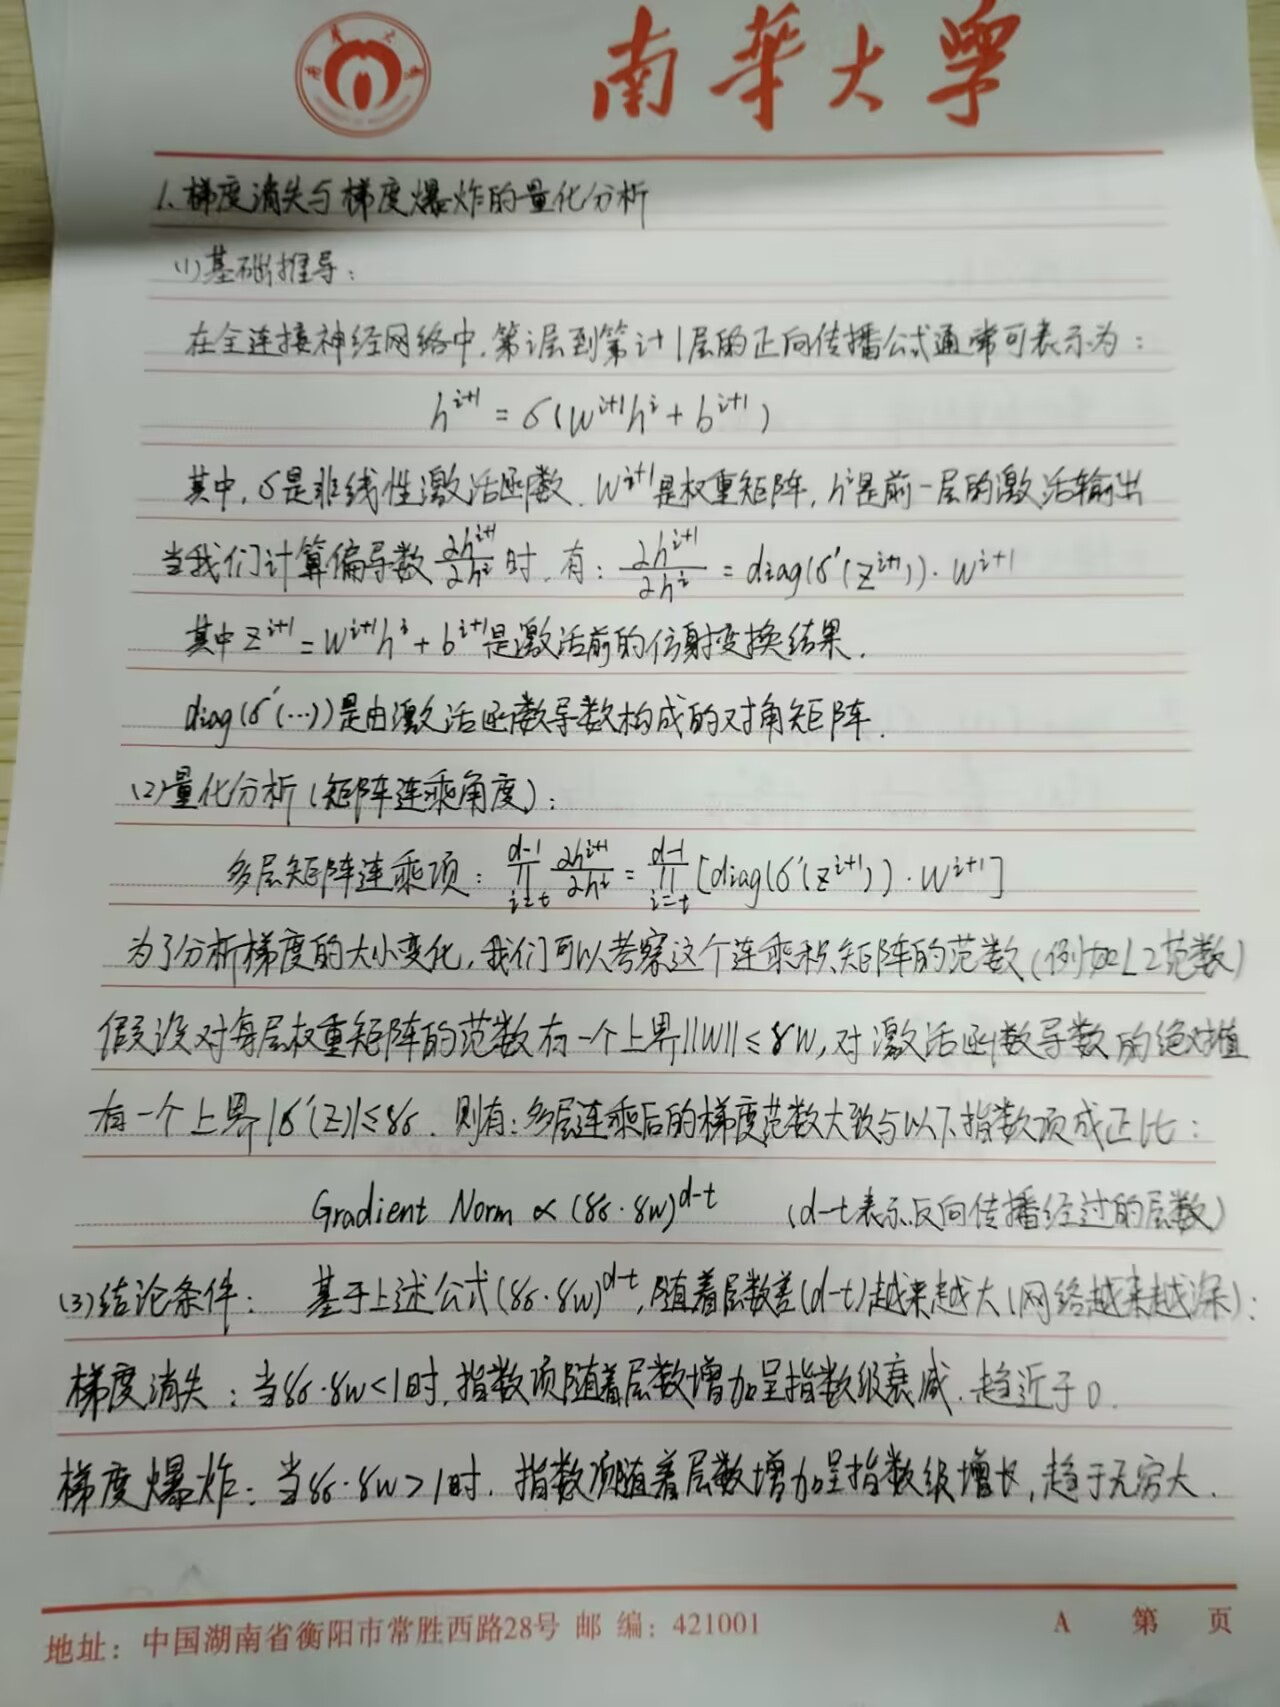
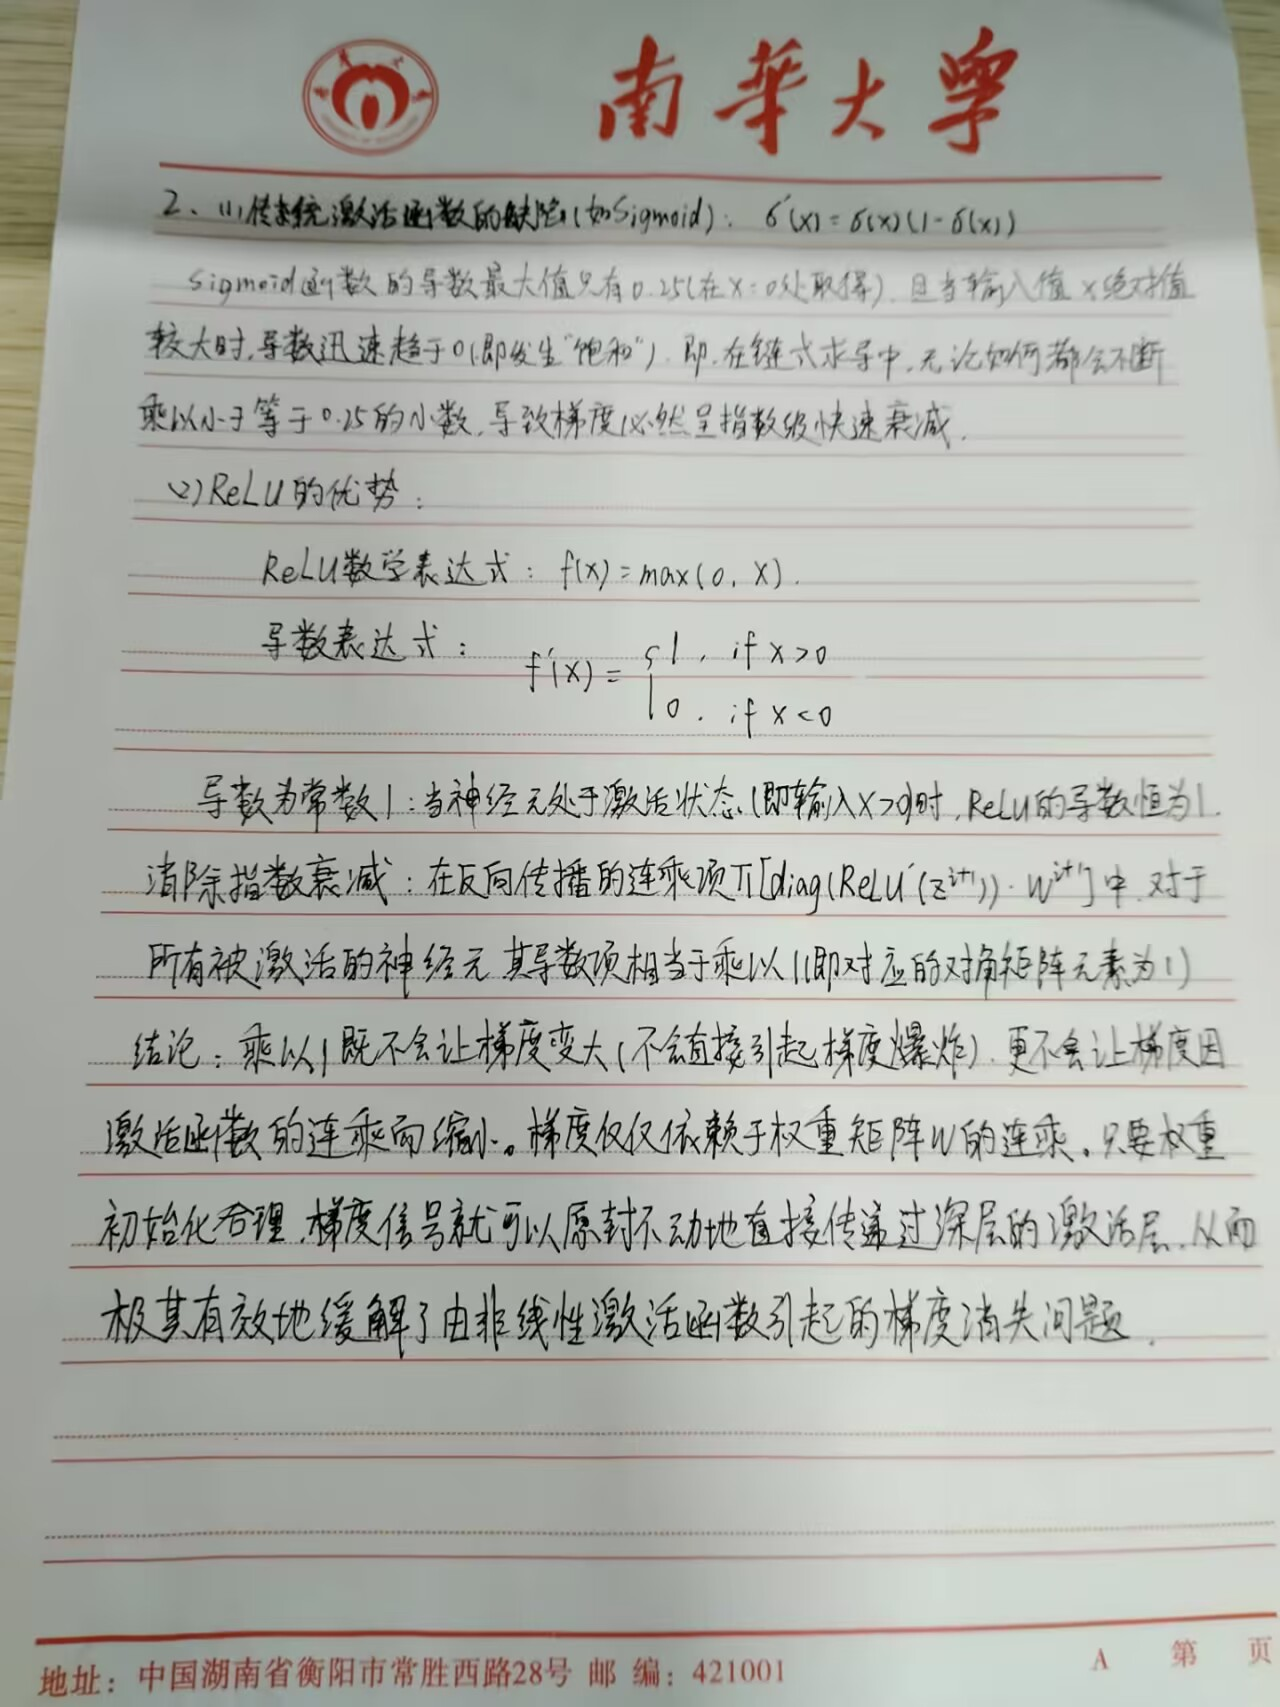

In [1]:
import torch
import torch.nn as nn

torch.manual_seed(42)

def build_deep_net(activation_fn):
    layers = []
    in_features = 256
    for _ in range(19):
        layers.append(nn.Linear(in_features, 256))
        layers.append(activation_fn())
        in_features = 256
    layers.append(nn.Linear(in_features, 10))
    return nn.Sequential(*layers)

def test_network_gradients(net, title):
    print(f"\n{'-'*50}")
    print(f"--- 实验: {title} ---")
    
    x = torch.randn(32, 256)
    y_true = torch.randn(32, 10)
    criterion = nn.MSELoss()
    
    try:
        y_pred = net(x)
        loss = criterion(y_pred, y_true)
        loss.backward()
        
        linear_layers = [m for m in net.modules() if isinstance(m, nn.Linear)]
        
        print(f"Loss 值: {loss.item()}")
        print(f"Layer 20 (靠近输出, 反向起点) 梯度范数: {linear_layers[19].weight.grad.norm().item():.4e}")
        print(f"Layer 10 (网络中间层)        梯度范数: {linear_layers[9].weight.grad.norm().item():.4e}")
        print(f"Layer 1  (靠近输入, 反向终点) 梯度范数: {linear_layers[0].weight.grad.norm().item():.4e}")
        
    except Exception as e:
        print(f"计算过程中出现错误/溢出: {e}")

# ========== 实验 1：梯度消失 ==========
print("=" * 50)
net_vanishing = build_deep_net(nn.Sigmoid)

def init_normal(m):
    if isinstance(m, nn.Linear):
        nn.init.normal_(m.weight, mean=0, std=1.0)
        nn.init.zeros_(m.bias)

net_vanishing.apply(init_normal)
test_network_gradients(net_vanishing, "梯度消失 (Sigmoid + Normal std=1)")

# ========== 实验 2：梯度爆炸 ==========
print("=" * 50)
net_exploding = build_deep_net(nn.ReLU)

def init_large(m):
    if isinstance(m, nn.Linear):
        nn.init.normal_(m.weight, mean=0, std=10.0)
        nn.init.zeros_(m.bias)

net_exploding.apply(init_large)
test_network_gradients(net_exploding, "梯度爆炸/NaN (ReLU + Normal std=10)")

# ========== 实验 3：稳定网络 ==========
print("=" * 50)
net_stable = build_deep_net(nn.ReLU)

def init_xavier(m):
    if isinstance(m, nn.Linear):
        nn.init.xavier_uniform_(m.weight)
        nn.init.zeros_(m.bias)

net_stable.apply(init_xavier)
test_network_gradients(net_stable, "稳定网络 (ReLU + Xavier Initialization)")


--------------------------------------------------
--- 实验: 梯度消失 (Sigmoid + Normal std=1) ---
Loss 值: 136.15806579589844
Layer 20 (靠近输出, 反向起点) 梯度范数: 7.9707e+01
Layer 10 (网络中间层)        梯度范数: 7.9742e+01
Layer 1  (靠近输入, 反向终点) 梯度范数: 8.1596e+02

--------------------------------------------------
--- 实验: 梯度爆炸/NaN (ReLU + Normal std=10) ---
Loss 值: nan
Layer 20 (靠近输出, 反向起点) 梯度范数: nan
Layer 10 (网络中间层)        梯度范数: nan
Layer 1  (靠近输入, 反向终点) 梯度范数: nan

--------------------------------------------------
--- 实验: 稳定网络 (ReLU + Xavier Initialization) ---
Loss 值: 0.8135774731636047
Layer 20 (靠近输出, 反向起点) 梯度范数: 1.8811e-03
Layer 10 (网络中间层)        梯度范数: 3.5737e-03
Layer 1  (靠近输入, 反向终点) 梯度范数: 3.4152e-03


泛化表现，协变量偏移和对抗性数据

1. 协变量偏移:实际生活例子（语音识别场景）：
假设我们开发了一款语音转文字的 AI 助手。
训练环境： 我们收集了大量专业播音员在安静录音棚里朗读的普通话音频（特征 x）。此时 
P train(x)集中在清晰、标准的声波特征上。
实际应用环境： 软件上线后，大量带有浓重地方口音的老年人在嘈杂的大街上使用它（测试集）。此时 P test(x)的声波特征变得杂乱、频率各异。
为什么满足条件： 显然，输入的音频特征分布变了，即 P(x) ≠ Q(x)。但是，无论是一句极其标准的“你好”，还是一句口音极重的“你好”，只要声波特征 x 确确实实发出了那个物理层面的声音，它对应的文字 y依然是“你好”。也就是说，从特定音频特征映射到具体文字的规则没有改变，即 P(y∣x)=Q(y∣x)。
2. 标签偏移:实际生活例子（医疗疾病预测场景）：
假设我们开发了一个通过病人的症状（特征 x，如体温、咳嗽频率）来预测是否感染某种流行性流感（标签 y）的模型。
训练环境： 我们在夏季收集了医院的数据。在夏季，流感发病率极低，1000 个病人里可能只有 5 个得流感。此时 P train(y=流感)极低。
实际应用环境： 模型在 冬季（流感爆发季）投入使用。此时医院里流感患者激增，1000 个病人里有 300 个是流感。显然，疾病的发生率变了，即 P(y) ≠ Q(y)。
为什么满足条件： 尽管得病的人变多了，但疾病本身的生物学特性没有变。也就是说，如果一个人确实得了流感（给定条件 y），那么他出现高烧、咳嗽等症状（特征 x）的概率，无论是在夏季还是冬季，都是完全一致的。这就满足了 P(x∣y)=Q(x∣y)。
3. 两者的区别与联系
【区别】：因果方向的假设不同
区分两者的核心在于理解 x 和 y 之间谁是“因”，谁是“果”。
协变量偏移 (X→Y)： 通常假设特征决定了标签。例如在图像识别中，图片的像素构成（x）决定了这到底是一只猫还是狗（y）。像素构成的分布变了（比如从白天变黑夜），导致了协变量偏移。
标签偏移 (Y→X)： 通常假设标签决定了特征。正如上述医疗例子，是先有“感染流感病毒”这个生理事实（y），才导致了“发烧咳嗽”这些外在症状（x）。疾病爆发导致 y 分布改变，进而引发了标签偏移。
【联系】：导致的后果与解决思路相似
性能退化： 如果不加处理，无论是协变量偏移还是标签偏移，都会导致在原训练集上表现优异的模型，在实际应用场景中性能大幅下降。
纠正机制相似（重要性加权）： 解决这两种偏移的经典方法都是重新加权（Reweighting）。
对于协变量偏移：如果某个特征样本在测试集中很常见，在训练集中很罕见，我们在训练时就给它分配更大的权重（权重比例为 Q(x)/P(x)）。
对于标签偏移：如果某类疾病在冬季测试集中爆发，我们在使用夏季数据训练时，就给得这种病的样本分配更大的权重（权重比例为 Q(y)/P(y)）。

In [9]:
import numpy as np
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.metrics import mean_squared_error

# 设置随机种子以保证结果可复现
np.random.seed(42)

# ==========================================
# 1. & 2. 人工数据集构造 (模拟协变量偏移)
# ==========================================
n_train = 1000
n_test = 500

# 训练集 P: 特征服从 N(-1, 1)
X_train = np.random.normal(loc=-1.0, scale=1.0, size=(n_train, 1))
# 为了让偏移修正效果更明显，我们在生成 y 时加入一点点非线性或较大的噪声
# （因为如果完全是完美的线性关系 y=2x+e，普通线性回归无论在哪里训练都能完美泛化）
noise_train = np.random.normal(loc=0.0, scale=1.5, size=(n_train, 1))
y_train = X_train**2 + 2 * X_train + noise_train 

# 测试集 Q: 特征服从 N(2, 1) -> 发生了明显的协变量偏移 (特征分布变了)
X_test = np.random.normal(loc=2.0, scale=1.0, size=(n_test, 1))
noise_test = np.random.normal(loc=0.0, scale=1.0, size=(n_test, 1))
y_test = X_test**2 + 2 * X_test + noise_test 

print("数据生成完毕。")
print(f"训练集特征均值: {np.mean(X_train):.2f}, 测试集特征均值: {np.mean(X_test):.2f}")


# ==========================================
# 3. 基线模型：直接在训练集 P 上训练并评估
# ==========================================
model_base = LinearRegression()
model_base.fit(X_train, y_train)

preds_base = model_base.predict(X_test)
mse_base = mean_squared_error(y_test, preds_base)

print(f"\n[基线模型] 直接训练的测试集 MSE: {mse_base:.4f}")


# ==========================================
# 4. 偏移校正实现 (计算重要性权重)
# ==========================================
# (a) 将训练集标记为 0，测试集标记为 1，合并训练分类器
X_combined = np.vstack((X_train, X_test))
y_domain = np.hstack((np.zeros(n_train), np.ones(n_test)))

# 训练逻辑回归分类器区分数据来源
domain_clf = LogisticRegression()
domain_clf.fit(X_combined, y_domain)

# 预测训练集样本属于测试集的概率 P(test|x)
# predict_proba 返回两列，第0列是 P(train|x)，第1列是 P(test|x)
probs = domain_clf.predict_proba(X_train)
p_train_given_x = probs[:, 0]
p_test_given_x = probs[:, 1]

# (b) 根据公式计算权重 wi ∝ P(test|xi) / P(train|xi)
# 加上 1e-5 是为了防止分母为 0 导致除零错误
weights = p_test_given_x / (p_train_given_x + 1e-5)

# 为了维持训练过程的数值稳定性，通常会将权重标准化，使其均值为 1
weights = weights / np.mean(weights)


# ==========================================
# 5. 加权模型训练与对比
# ==========================================
model_weighted = LinearRegression()
# 使用 sample_weight 参数传入我们计算出的修正权重
model_weighted.fit(X_train, y_train, sample_weight=weights)

preds_weighted = model_weighted.predict(X_test)
mse_weighted = mean_squared_error(y_test, preds_weighted)

print(f"[加权模型] 经过权重修正后的测试集 MSE: {mse_weighted:.4f}")

# 验证校正效果
if mse_weighted < mse_base:
    print(f"-> 结论: 修正成功！MSE 降低了 {(mse_base - mse_weighted):.4f}")
else:
    print("-> 结论: 修正效果不明显。")

数据生成完毕。
训练集特征均值: -0.98, 测试集特征均值: 1.99

[基线模型] 直接训练的测试集 MSE: 107.0249
[加权模型] 经过权重修正后的测试集 MSE: 4.8084
-> 结论: 修正成功！MSE 降低了 102.2165
